<a href="https://colab.research.google.com/github/prijess/Data/blob/main/Quiz_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Curve Fitting dengan Dataset yang Sudah Ada**

Bagian ini menunjukkan bagaimana melakukan *curve fitting* pada dataset yang sudah dimuat ke dalam DataFrame. Anda perlu mengganti `df` dengan DataFrame Anda yang sebenarnya dan menyesuaikan nama kolom `x_column` dan `y_column`.

Data berhasil dimuat dari GitHub.

5 baris pertama dari DataFrame:
  Destination Country    Origin Country     2015     2016     2017     2018  \
0           Indonesia    Australia [AU]  1099058  1302292  1256927  1301478   
1           Indonesia        China [CN]  1260700  1556771  2093171  2139161   
2           Indonesia        Japan [JP]   549705   545392   573310   530573   
3           Indonesia        India [IN]   319608   422045   536902   595636   
4           Indonesia  New Zealand [NZ]    87923   105393   106914   128366   

      2019    2020  
0  1386803  256291  
1  2072252  239768  
2   519623   92228  
3   657300  111724  
4   149010   19947  

Nama-nama kolom yang tersedia di DataFrame:
['Destination Country', 'Origin Country', '2015', '2016', '2017', '2018', '2019', '2020']

Polinomial Coefficient for China [CN] (from the highest degree to the lowest): [-2.33143054e+05  9.40631872e+08 -9.48758933e+11]
Polinomial Formula for China [CN]: 
            2
-2.331e+05 x + 9.

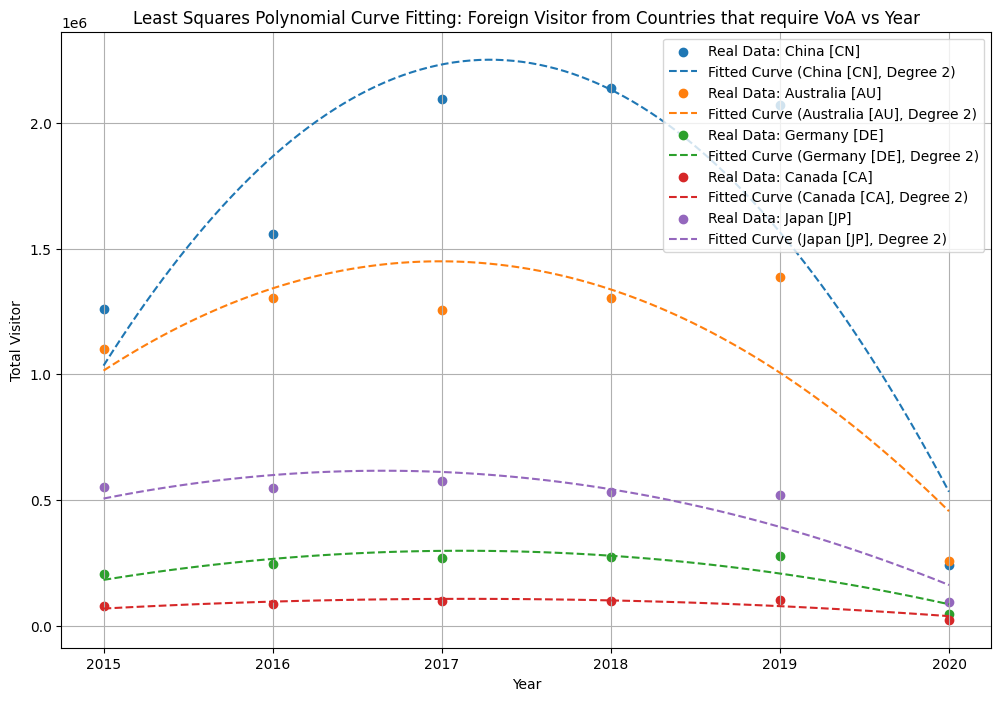

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Asumsi: DataFrame Anda sudah dimuat ---
# Mengganti contoh DataFrame dengan membaca langsung dari URL GitHub yang Anda berikan
csv_url = 'https://raw.githubusercontent.com/prijess/Data/main/data%20visitor%20fix.csv' # Corrected URL

try:
    df_existing = pd.read_csv(csv_url)
    print("Data berhasil dimuat dari GitHub.")

    # Menampilkan 5 baris pertama dan nama kolom untuk inspeksi
    print("\n5 baris pertama dari DataFrame:")
    print(df_existing.head())
    print("\nNama-nama kolom yang tersedia di DataFrame:")
    print(df_existing.columns.tolist())

except Exception as e:
    print(f"Error saat memuat data dari GitHub: {e}")
    print("Menggunakan data contoh hardcoded sebagai fallback.")
    df_existing = pd.DataFrame({
        'year': [2015, 2016, 2017, 2018, 2019],
        'visitor': [10000, 100000, 300000, 500000, 1000000],
        'other_data': np.random.rand(5) * 100
    })

# --- Konfigurasi: Tentukan kolom untuk X dan Y ---
# Karena data memiliki tahun sebagai kolom, kita akan mengekstraknya secara dinamis
# Anda bisa memilih beberapa 'Origin Country' untuk dianalisis
selected_origin_countries = ['China [CN]', 'Australia [AU]', 'Germany [DE]', 'Canada [CA]', 'Japan [JP]'] # Ganti dengan daftar negara asal yang ingin Anda analisis
polynomial_degree = 2      # Derajat polinomial yang ingin di-fit (misal: 1 untuk linear, 2 untuk kuadratik)

# --- Ekstraksi dan Pemrosesan data --- #
# Identifikasi kolom tahun secara dinamis
year_columns = [col for col in df_existing.columns if col.isdigit() and len(col) == 4]
if not year_columns:
    print("Tidak ada kolom tahun yang ditemukan di DataFrame. Menggunakan data contoh hardcoded sebagai fallback.")
    x_data_fallback = np.array([1, 2, 3, 4, 5, 6, 7, 8])
    y_data_fallback = np.array([12, 15, 20, 22, 19, 18, 17, 16])
else:
    x_data = np.array([int(year) for year in year_columns])

plt.figure(figsize=(12, 8))
# Address MatplotlibDeprecationWarning by using plt.colormaps.get_cmap()
colors = plt.colormaps.get_cmap('tab10') # Removed the second argument as it's no longer needed or accepted

for i, country in enumerate(selected_origin_countries):
    try:
        # Filter data berdasarkan negara asal yang dipilih
        df_country = df_existing[df_existing['Origin Country'] == country]

        if df_country.empty:
            print(f"Origin Country '{country}' tidak ditemukan di DataFrame. Melanjutkan ke negara berikutnya.")
            continue

        y_data = df_country[year_columns].iloc[0].values.astype(float)

        # Pastikan x_data dan y_data memiliki panjang yang sama
        if len(x_data) != len(y_data):
            print(f"Panjang data X dan Y tidak cocok untuk '{country}'. Melanjutkan ke negara berikutnya.")
            continue

        # --- Step 1: Fit a polynomial curve ---
        coefficients = np.polyfit(x_data, y_data, polynomial_degree)
        polynomial_model = np.poly1d(coefficients)

        # --- Step 2: Plot the original data and the fitted curve ---
        plt.scatter(x_data, y_data, color=colors(i), label=f'Real Data: {country}') # Plot the original data points

        # Generate a smoother range for plotting the fitted curve
        x_fit = np.linspace(min(x_data), max(x_data), 100)
        y_fit = polynomial_model(x_fit) # Predict y values using the fitted model

        plt.plot(x_fit, y_fit, color=colors(i), linestyle='--', label=f'Fitted Curve ({country}, Degree {polynomial_degree})') # Plot the polynomial curve

        print(f"\nPolinomial Coefficient for {country} (from the highest degree to the lowest): {coefficients}")
        print(f"Polinomial Formula for {country}: \n{polynomial_model}")

    except KeyError as e:
        print(f"Error: Kolom '{e}' tidak ditemukan di DataFrame untuk '{country}'. Mohon periksa kembali nama kolom atau nilai `selected_origin_countries`.")
    except Exception as e:
        print(f"Terjadi kesalahan saat memproses data untuk '{country}': {e}")

plt.title(f'Least Squares Polynomial Curve Fitting: Foreign Visitor from Countries that require VoA vs Year')
plt.xlabel('Year')
plt.ylabel('Total Visitor')
plt.legend()
plt.grid(True)
plt.show()

Add interpretation sama and implication*
